In [1]:

!pip install -q segmentation-models-pytorch

# ── Standard library imports ──
import os
import shutil
import json
import random
import numpy as np
from pathlib import Path

# ── PyTorch ──
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F

# ── Image processing ──
from PIL import Image
import cv2
import albumentations as A
from albumentations.pytorch import ToTensorV2

# ── Pretrained models ──
import timm
import segmentation_models_pytorch as smp

# ── Metrics & plots ──
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, f1_score
)
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from tqdm.notebook import tqdm

# ── Kaggle Specific Paths ──
# On Kaggle, your data is always in /kaggle/input/
# Your outputs (weights, logs) must be saved to /kaggle/working/
INPUT_DIR = Path('/kaggle/input')
WORKING_DIR = Path('/kaggle/working')

# ── Reproducibility ──
SEED = 42
def seed_everything(seed):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 4.1 MB/s eta 0:00:0000:01
Using device: cuda
GPU: Tesla T4


In [2]:
import os
from pathlib import Path


input_path = Path('/kaggle/input')

print("--- Searching for Kidney Dataset ---")
found = False
for path in input_path.rglob('*'):
   
    if path.is_dir() and "Normal" in [sub.name for sub in path.iterdir() if sub.is_dir()]:
        print(f"✅ FOUND IT! Use this path for your data loader:")
        print(f"DATA_DIR = '{path}'")
        found = True
        break

if not found:
    print("❌ Still not found. Did you click '+ Add Data' on the right sidebar?")

--- Searching for Kidney Dataset ---
✅ FOUND IT! Use this path for your data loader:
DATA_DIR = '/kaggle/input/datasets/nazmul0087/ct-kidney-dataset-normal-cyst-tumor-and-stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone'


Classification root: /kaggle/input/datasets/nazmul0087/ct-kidney-dataset-normal-cyst-tumor-and-stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone
  Cyst: 3709 images
  Normal: 5077 images
  Stone: 1377 images
  Tumor: 2283 images


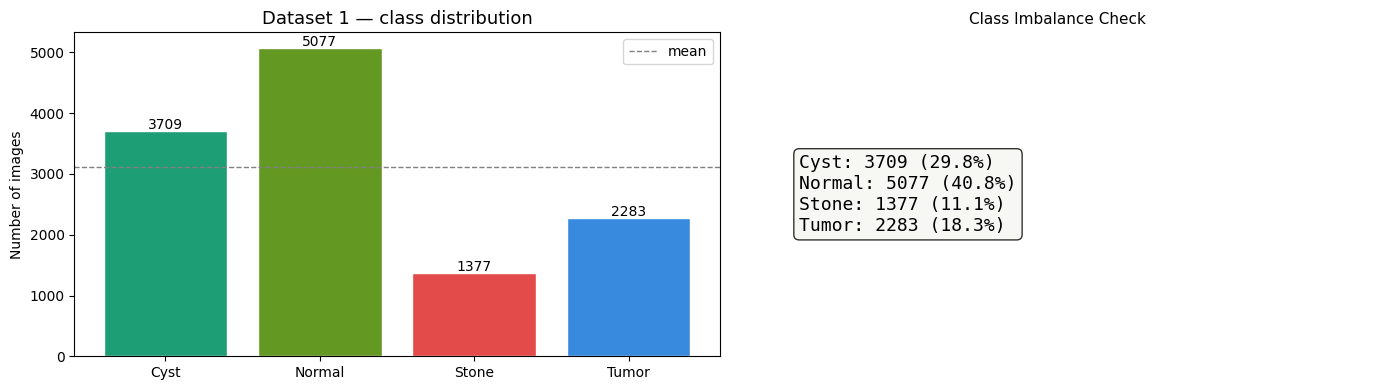

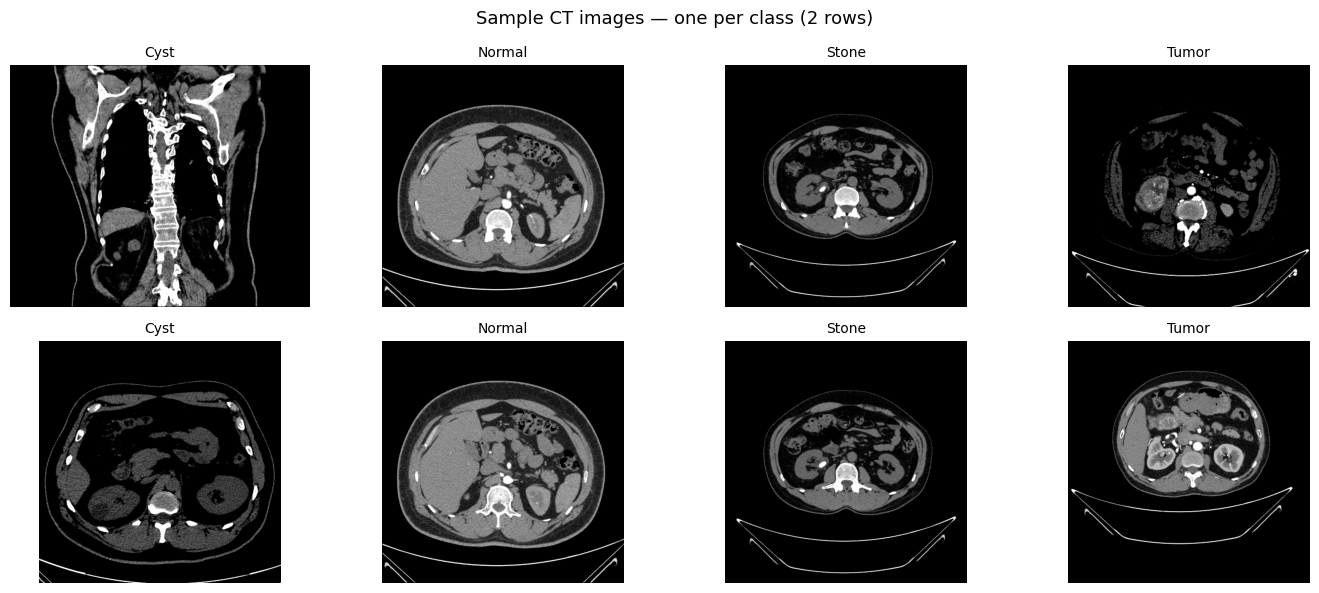

Exploration done. Visualizations saved to /kaggle/working/


In [3]:
# ─────────────────────────────────────────────────────────────────
# CELL 4 — Explore datasets visually (Kaggle Version)
# ─────────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path


CLS_ROOT = Path('/kaggle/input/datasets/nazmul0087/ct-kidney-dataset-normal-cyst-tumor-and-stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone')

print(f'Classification root: {CLS_ROOT}')

CLASS_NAMES = ['Cyst', 'Normal', 'Stone', 'Tumor']
counts = {}
for cls in CLASS_NAMES:
    folder = CLS_ROOT / cls
    # Search for both jpg and png files
    imgs = list(folder.glob('*.jpg')) + list(folder.glob('*.png'))
    counts[cls] = len(imgs)
    print(f'  {cls}: {len(imgs)} images')

# ── Bar chart ──
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

colors = ['#1D9E75', '#639922', '#E24B4A', '#378ADD']
axes[0].bar(counts.keys(), counts.values(), color=colors, edgecolor='white')
axes[0].set_title('Dataset 1 — class distribution', fontsize=13)
axes[0].set_ylabel('Number of images')
for i, (k, v) in enumerate(counts.items()):
    axes[0].text(i, v + 30, str(v), ha='center', fontsize=10)
axes[0].axhline(y=sum(counts.values())/len(counts), color='gray',
                linestyle='--', linewidth=1, label='mean')
axes[0].legend()

# ── Statistics Display ──
axes[1].axis('off')
axes[1].set_title('Class Imbalance Check', fontsize=11)
total_imgs = sum(counts.values())
imbalance_text = '\n'.join([f'{k}: {v} ({v/total_imgs*100:.1f}%)'
                             for k, v in counts.items()])
axes[1].text(0.1, 0.5, imbalance_text, transform=axes[1].transAxes,
             fontsize=13, verticalalignment='center',
             fontfamily='monospace',
             bbox=dict(boxstyle='round', facecolor='#f5f5f0', alpha=0.8))

plt.tight_layout()
# Save to Kaggle working directory so you can download it for your report
plt.savefig('/kaggle/working/class_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

# ── Show sample images per class ──
fig, axes = plt.subplots(2, 4, figsize=(14, 6))
fig.suptitle('Sample CT images — one per class (2 rows)', fontsize=13)
for col, cls in enumerate(CLASS_NAMES):
    folder = CLS_ROOT / cls
    # Get first 2 images
    imgs = sorted(list(folder.glob('*.jpg')) + list(folder.glob('*.png')))[:2]
    for row, img_path in enumerate(imgs):
        img = Image.open(img_path).convert('L')  # grayscale CT
        axes[row][col].imshow(img, cmap='gray')
        axes[row][col].set_title(cls, fontsize=10)
        axes[row][col].axis('off')

plt.tight_layout()
# Save sample visualization for your 15-20 page report
plt.savefig('/kaggle/working/sample_images.png', dpi=120, bbox_inches='tight')
plt.show()

print('Exploration done. Visualizations saved to /kaggle/working/')

In [4]:
# ─────────────────────────────────────────────────────────────────
# CELL 5 — KidneyClassificationDataset (Kaggle Ready)
# ─────────────────────────────────────────────────────────────────
import albumentations as A
from albumentations.pytorch import ToTensorV2
import cv2
import random
from torch.utils.data import Dataset, DataLoader

# Ensure CLS_ROOT is a Path object (inherited from previous cell)
# CLS_ROOT = Path('/kaggle/input/datasets/nazmul0087/ct-kidney-dataset-normal-cyst-tumor-and-stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone')

CLASS_TO_IDX = {'Cyst': 0, 'Normal': 1, 'Stone': 2, 'Tumor': 3}
IDX_TO_CLASS = {v: k for k, v in CLASS_TO_IDX.items()}
IMG_SIZE     = 224   

# ── Augmentation for training ──
train_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.RandomRotate90(p=0.5),
    A.RandomBrightnessContrast(p=0.4),
    A.GaussNoise(p=0.2),
    A.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]),
    ToTensorV2()
])

# ── Validation/Test transforms ──
val_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]),
    ToTensorV2()
])

class KidneyClassDataset(Dataset):
    def __init__(self, root, transform=None):
        self.samples   = []
        self.transform = transform

        for cls_name, label in CLASS_TO_IDX.items():
            folder = Path(root) / cls_name
            # Kaggle paths are case-sensitive; checking both just in case
            if not folder.exists():
                folder = Path(root) / cls_name.lower()
            
            # Efficiently collect all image paths
            for ext in ['*.jpg', '*.png', '*.jpeg']:
                for img_path in folder.glob(ext):
                    self.samples.append((str(img_path), label))

        print(f'Dataset loaded: {len(self.samples)} total images')

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = cv2.imread(path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        if self.transform:
            img = self.transform(image=img)['image']
        return img, label

# ── Build full dataset first, then split ──
full_dataset = KidneyClassDataset(CLS_ROOT, transform=None)
total = len(full_dataset)

n_train = int(0.70 * total)
n_val   = int(0.15 * total)
n_test  = total - n_train - n_val

indices = list(range(total))
random.seed(42) # For reproducibility
random.shuffle(indices)

train_idx = indices[:n_train]
val_idx   = indices[n_train:n_train+n_val]
test_idx  = indices[n_train+n_val:]

# Helper class to apply specific transforms to subsets
class SubsetWithTransform(Dataset):
    def __init__(self, base_dataset, indices, transform):
        self.base      = base_dataset
        self.indices   = indices
        self.transform = transform
    def __len__(self):
        return len(self.indices)
    def __getitem__(self, idx):
        path, label = self.base.samples[self.indices[idx]]
        img = cv2.imread(path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = self.transform(image=img)['image']
        return img, label

train_ds = SubsetWithTransform(full_dataset, train_idx, train_transform)
val_ds   = SubsetWithTransform(full_dataset, val_idx,   val_transform)
test_ds  = SubsetWithTransform(full_dataset, test_idx,  val_transform)

# ── DataLoaders ──
BATCH_SIZE = 16
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)

print(f'Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}')

Dataset loaded: 12446 total images
Train: 8712 | Val: 1866 | Test: 1868


In [5]:
# ─────────────────────────────────────────────────────────────────
# CELL 6 — EfficientNet-B Classifier (Kaggle Ready)
# ─────────────────────────────────────────────────────────────────
import torch.nn as nn
from torchvision import models

# Set device (Kaggle typically uses 'cuda' if GPU is enabled)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
NUM_CLASSES = 4

class KidneyClassifier(nn.Module):
    def __init__(self, num_classes=4, dropout=0.4):
        super().__init__()

        # Loading EfficientNet_B0 with pretrained weights
        self.cnn = models.efficientnet_b0(
            weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1
        )

        # Freeze early layers — only fine-tune the last blocks
        # This matches your logic for fine-tuning specific feature sets
        for name, param in self.cnn.named_parameters():
            if 'features.6' in name or 'features.7' in name or 'features.8' in name:
                param.requires_grad = True
            else:
                param.requires_grad = False  # freeze everything else

        # Replace classifier head to match your 4 kidney classes
        in_features = self.cnn.classifier[1].in_features
        self.cnn.classifier = nn.Sequential(
            nn.Dropout(p=dropout),
            nn.Linear(in_features, 256),
            nn.SiLU(),
            nn.Dropout(p=0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.cnn(x)

# Initialize and move to GPU
cls_model = KidneyClassifier(num_classes=NUM_CLASSES).to(DEVICE)

# Verify trainable parameters
trainable = sum(p.numel() for p in cls_model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in cls_model.parameters())
print(f'Device: {DEVICE}')
print(f'Trainable: {trainable:,} / {total:,} ({100*trainable/total:.1f}%)')

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 136MB/s]


Device: cuda
Trainable: 3,484,704 / 4,336,512 (80.4%)


In [6]:
# ─────────────────────────────────────────────────────────────────
# CELL 7 — Loss, Optimizer, Scheduler (Kaggle Ready)
# ─────────────────────────────────────────────────────────────────
import torch
import torch.optim as optim
from tqdm.auto import tqdm

# 1. Count per class in train set to calculate weights
label_counts = {0: 0, 1: 0, 2: 0, 3: 0}   # Cyst, Normal, Stone, Tumor

# We use tqdm here because iterating through the dataset can take a minute
print('Calculating class weights...')
for i in tqdm(range(len(train_ds))):
    _, label = train_ds[i]
    label_counts[int(label)] += 1

print('\nTraining set class counts:')
for idx, name in IDX_TO_CLASS.items():
    print(f'  {name} (class {idx}): {label_counts[idx]}')

# 2. Compute inverse-frequency weights
total_train = sum(label_counts.values())
num_classes = 4
weights = [
    total_train / (num_classes * label_counts[i])
    for i in range(num_classes)
]
class_weights = torch.tensor(weights, dtype=torch.float32).to(DEVICE)
print(f'\nClass weights: {[f"{w:.3f}" for w in weights]}')

# 3. Loss function with Weights
criterion = nn.CrossEntropyLoss(weight=class_weights)

# 4. Optimizer: AdamW
# Differential learning rates: slower for the CNN, faster for the new head
optimizer = optim.AdamW([
    {'params': [p for n,p in cls_model.named_parameters() 
                if p.requires_grad and 'classifier' not in n], 'lr': 5e-5},
    {'params': cls_model.cnn.classifier.parameters(), 'lr': 1e-4},
], weight_decay=1e-3)

# 5. Learning rate scheduler
NUM_EPOCHS = 15
scheduler  = optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=NUM_EPOCHS, eta_min=1e-6
)

print(f'\nOptimizer: AdamW')
print(f'Scheduler: CosineAnnealing over {NUM_EPOCHS} epochs')

Calculating class weights...


  0%|          | 0/8712 [00:00<?, ?it/s]


Training set class counts:
  Cyst (class 0): 2638
  Normal (class 1): 3549
  Stone (class 2): 946
  Tumor (class 3): 1579

Class weights: ['0.826', '0.614', '2.302', '1.379']

Optimizer: AdamW
Scheduler: CosineAnnealing over 15 epochs


In [7]:
# ─────────────────────────────────────────────────────────────────
# CELL 8 — Training loop for classifier + Early Stopping (Kaggle)
# ─────────────────────────────────────────────────────────────────
history = {'train_loss': [], 'val_loss': [],
           'train_acc':  [], 'val_acc':  []}

best_val_acc    = 0.0
# CHANGE: Save to /kaggle/working/ so you can find the file later
best_model_path = '/kaggle/working/classifier_best.pth'

# ── Early stopping settings ──
PATIENCE        = 5     # stop if no improvement for 5 epochs
es_counter      = 0     # counts epochs without improvement
early_stopped   = False

print(f"Starting training on {DEVICE}...")

for epoch in range(1, NUM_EPOCHS + 1):

    # ────────── TRAIN ──────────
    cls_model.train()
    train_loss, train_correct, train_total = 0, 0, 0

    for imgs, labels in tqdm(train_loader, desc=f'Epoch {epoch}/{NUM_EPOCHS} [Train]', leave=False):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = cls_model(imgs)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss    += loss.item() * imgs.size(0)
        preds          = outputs.argmax(dim=1)
        train_correct += (preds == labels).sum().item()
        train_total   += imgs.size(0)

    scheduler.step()

    # ────────── VALIDATE ──────────
    cls_model.eval()
    val_loss, val_correct, val_total = 0, 0, 0

    with torch.no_grad():
        for imgs, labels in tqdm(val_loader, desc=f'Epoch {epoch}/{NUM_EPOCHS} [Val]', leave=False):
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            outputs = cls_model(imgs)
            loss    = criterion(outputs, labels)
            val_loss    += loss.item() * imgs.size(0)
            preds        = outputs.argmax(dim=1)
            val_correct += (preds == labels).sum().item()
            val_total   += imgs.size(0)

    # ── Compute epoch metrics ──
    t_loss = train_loss / train_total
    v_loss = val_loss   / val_total
    t_acc  = train_correct / train_total * 100
    v_acc  = val_correct   / val_total   * 100

    history['train_loss'].append(t_loss)
    history['val_loss'].append(v_loss)
    history['train_acc'].append(t_acc)
    history['val_acc'].append(v_acc)

    print(f'Epoch {epoch:02d}/{NUM_EPOCHS} | '
          f'Loss: {t_loss:.4f}/{v_loss:.4f} | '
          f'Acc: {t_acc:.2f}%/{v_acc:.2f}% | '
          f'Patience: {es_counter}/{PATIENCE}')

    # ── Save best model + early stopping check ──
    if v_acc > best_val_acc:
        best_val_acc = v_acc
        es_counter   = 0    
        torch.save(cls_model.state_dict(), best_model_path)
        print(f'  ✓ New best val acc: {v_acc:.2f}% — model saved to {best_model_path}')
    else:
        es_counter += 1
        print(f'  ✗ No improvement ({es_counter}/{PATIENCE})')
        if es_counter >= PATIENCE:
            print(f'\n⚠ Early stopping triggered at epoch {epoch}!')
            early_stopped = True
            break

if not early_stopped:
    print(f'\nTraining complete (full {NUM_EPOCHS} epochs).')
print(f'Best val accuracy: {best_val_acc:.2f}%')

Starting training on cuda...


Epoch 1/15 [Train]:   0%|          | 0/545 [00:00<?, ?it/s]

Epoch 1/15 [Val]:   0%|          | 0/117 [00:00<?, ?it/s]

Epoch 01/15 | Loss: 0.8522/0.1547 | Acc: 68.56%/93.46% | Patience: 0/5
  ✓ New best val acc: 93.46% — model saved to /kaggle/working/classifier_best.pth


Epoch 2/15 [Train]:   0%|          | 0/545 [00:00<?, ?it/s]

...

Epoch 14/15 [Val]:   0%|          | 0/117 [00:00<?, ?it/s]

Epoch 14/15 | Loss: 0.1993/0.0044 | Acc: 92.68%/99.89% | Patience: 3/5
  ✗ No improvement (4/5)


Epoch 15/15 [Train]:   0%|          | 0/545 [00:00<?, ?it/s]

Epoch 15/15 [Val]:   0%|          | 0/117 [00:00<?, ?it/s]

Epoch 15/15 | Loss: 0.1947/0.0055 | Acc: 92.91%/99.84% | Patience: 4/5
  ✗ No improvement (5/5)

⚠ Early stopping triggered at epoch 15!
Best val accuracy: 99.89%


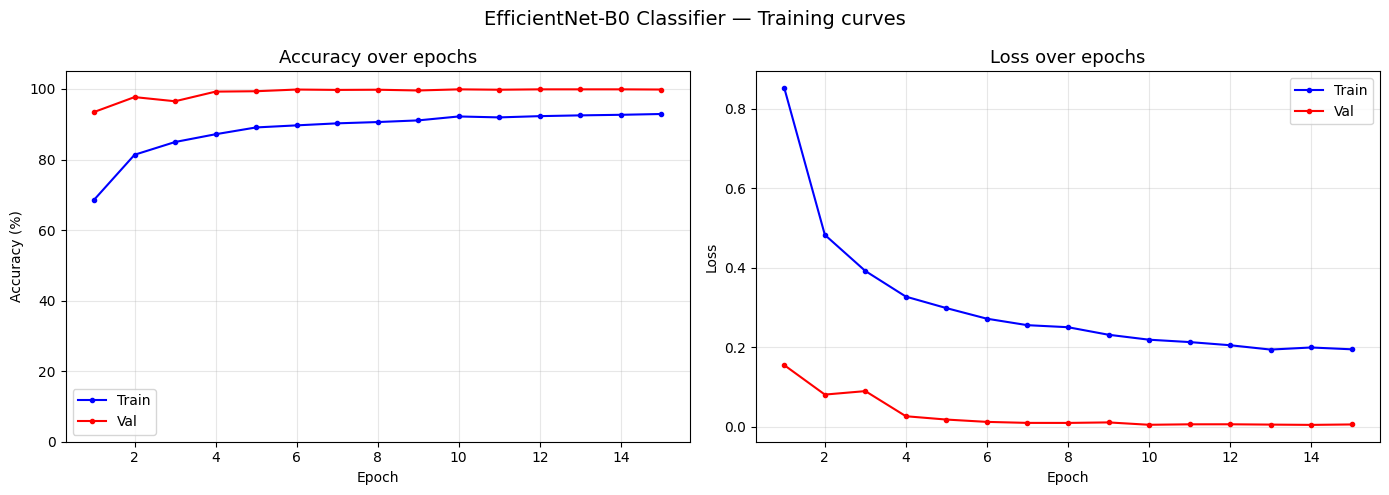

Curves saved to /kaggle/working/training_curves.png


In [8]:
# ─────────────────────────────────────────────────────────────────
# CELL 9 — Plot accuracy and loss curves (Kaggle Ready)
# ─────────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt

# We use the length of history to avoid errors if early stopping triggered
epochs = range(1, len(history['train_acc']) + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Accuracy ──
axes[0].plot(epochs, history['train_acc'], 'b-o', markersize=3, label='Train')
axes[0].plot(epochs, history['val_acc'],   'r-o', markersize=3, label='Val')
axes[0].set_title('Accuracy over epochs', fontsize=13)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy (%)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim([0, 105]) # Increased slightly to see 100% clearly

# ── Loss ──
axes[1].plot(epochs, history['train_loss'], 'b-o', markersize=3, label='Train')
axes[1].plot(epochs, history['val_loss'],   'r-o', markersize=3, label='Val')
axes[1].set_title('Loss over epochs', fontsize=13)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('EfficientNet-B0 Classifier — Training curves', fontsize=14)
plt.tight_layout()
# Save to Kaggle working directory
plt.savefig('/kaggle/working/training_curves.png', dpi=120, bbox_inches='tight')
plt.show()

print("Curves saved to /kaggle/working/training_curves.png")

Testing:   0%|          | 0/117 [00:00<?, ?it/s]

Test Accuracy:  99.95%
Test F1 (macro): 99.92%

Per-class report:
              precision    recall  f1-score   support

        Cyst       1.00      1.00      1.00       543
      Normal       1.00      1.00      1.00       761
       Stone       1.00      1.00      1.00       218
       Tumor       1.00      1.00      1.00       346

    accuracy                           1.00      1868
   macro avg       1.00      1.00      1.00      1868
weighted avg       1.00      1.00      1.00      1868



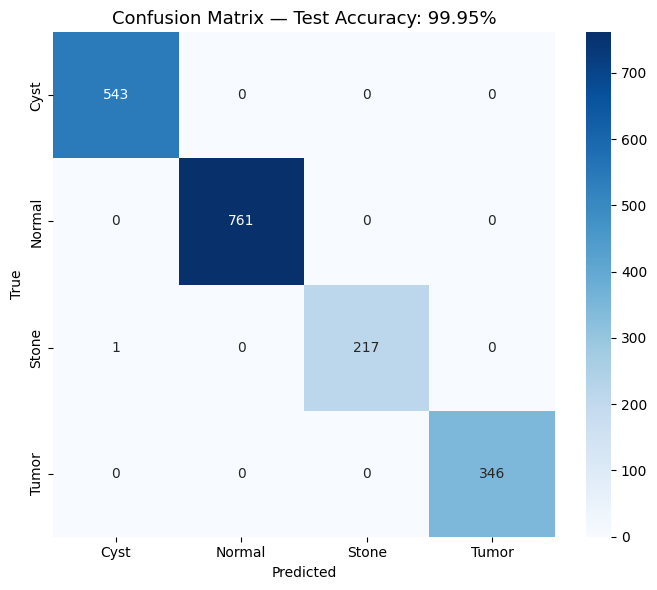

Evaluation complete. Results saved to /kaggle/working/confusion_matrix.png


In [9]:
# ─────────────────────────────────────────────────────────────────
# CELL 10 — Final evaluation on the test set (Kaggle Ready)
# ─────────────────────────────────────────────────────────────────
import numpy as np
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

# 1. Load the BEST saved weights
cls_model.load_state_dict(torch.load(best_model_path))
cls_model.eval()

all_preds  = []
all_labels = []

# 2. Run inference on the test set
with torch.no_grad():
    for imgs, labels in tqdm(test_loader, desc='Testing'):
        imgs = imgs.to(DEVICE)
        outputs = cls_model(imgs)
        preds   = outputs.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

# 3. Metrics calculation
test_acc = accuracy_score(all_labels, all_preds) * 100
test_f1  = f1_score(all_labels, all_preds, average='macro') * 100
print(f'Test Accuracy:  {test_acc:.2f}%')
print(f'Test F1 (macro): {test_f1:.2f}%')

# 4. Detailed Classification Report (Precision, Recall, F1 per class)
# Note: Ensure CLASS_NAMES matches your IDX_TO_CLASS ['Cyst', 'Normal', 'Stone', 'Tumor']
print('\nPer-class report:')
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))

# 5. Confusion matrix visualization
cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES,
            yticklabels=CLASS_NAMES, ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title(f'Confusion Matrix — Test Accuracy: {test_acc:.2f}%', fontsize=13)
plt.tight_layout()

# Save to Kaggle working directory
plt.savefig('/kaggle/working/confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()

print("Evaluation complete. Results saved to /kaggle/working/confusion_matrix.png")

In [10]:
import kagglehub
import os
from pathlib import Path

# 1. Download the latest version
path = kagglehub.dataset_download("murillobouzon/kssd2025-kidney-stone-segmentation-dataset")
print("Path to dataset files:", path)

# 2. Define the exact subfolders
# Based on the KSSD2025 structure, we look for 'images' and 'masks'
seg_base = Path(path) / 'KSSD2025'
seg_images = sorted(list(seg_base.glob('images/*.tif')))
seg_masks = sorted(list(seg_base.glob('masks/*.png')))

print(f"✅ Success! Found {len(seg_images)} images and {len(seg_masks)} masks.")

Path to dataset files: /kaggle/input/datasets/murillobouzon/kssd2025-kidney-stone-segmentation-dataset
✅ Success! Found 0 images and 0 masks.


✅ Total CT Scans: 838
✅ Total Expert Masks: 838


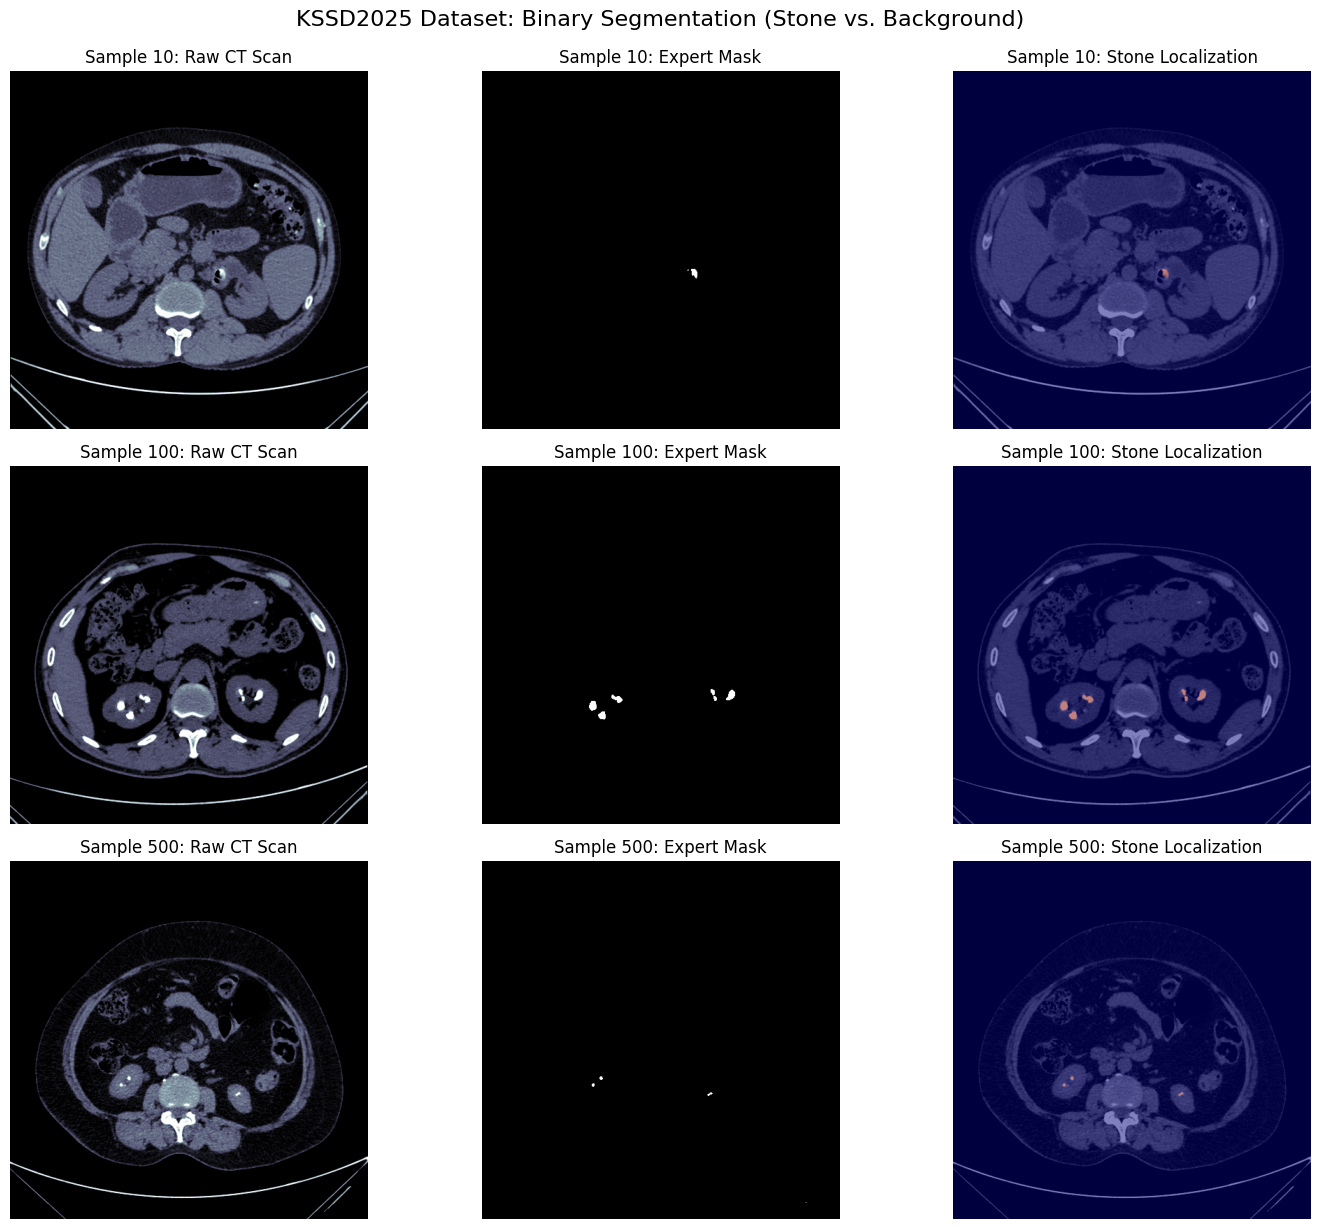

In [11]:
import matplotlib.pyplot as plt
import cv2
import numpy as np
from pathlib import Path

# 1. SETUP PATHS
# Using the exact paths found by your search earlier
base_dir = Path('/kaggle/input/datasets/murillobouzon/kssd2025-kidney-stone-segmentation-dataset/data')
seg_images = sorted(list((base_dir / 'image').glob('*.tif')))
seg_labels = sorted(list((base_dir / 'label').glob('*.tif')))

print(f"✅ Total CT Scans: {len(seg_images)}")
print(f"✅ Total Expert Masks: {len(seg_labels)}")

# 2. VISUALIZATION
# We will show 3 random samples to see how the masks align with the stones
fig, axes = plt.subplots(3, 3, figsize=(15, 12))

# Indices to display (you can change these to see different samples)
sample_indices = [10, 100, 500] 

for i, idx in enumerate(sample_indices):
    # Load Image & Mask
    # Medical .tif files are loaded in grayscale (0-255)
    img = cv2.imread(str(seg_images[idx]), cv2.IMREAD_GRAYSCALE)
    mask = cv2.imread(str(seg_labels[idx]), cv2.IMREAD_GRAYSCALE)
    
    # A. The Raw CT Scan
    axes[i, 0].imshow(img, cmap='bone')
    axes[i, 0].set_title(f"Sample {idx}: Raw CT Scan")
    axes[i, 0].axis('off')
    
    # B. The Ground Truth Mask (The "Label")
    axes[i, 1].imshow(mask, cmap='gray')
    axes[i, 1].set_title(f"Sample {idx}: Expert Mask")
    axes[i, 1].axis('off')
    
    # C. The Overlay (How the doctor sees it)
    axes[i, 2].imshow(img, cmap='gray')
    # We color the mask red (jet) and make it transparent (alpha)
    axes[i, 2].imshow(mask, cmap='jet', alpha=0.5 if np.max(mask) > 0 else 0)
    axes[i, 2].set_title(f"Sample {idx}: Stone Localization")
    axes[i, 2].axis('off')

plt.tight_layout()
plt.suptitle("KSSD2025 Dataset: Binary Segmentation (Stone vs. Background)", fontsize=16, y=1.02)
plt.show()

In [13]:
# ─────────────────────────────────────────────────────────────────
# CELL 11 — Rebuild segmentation dataset for KSSD2025
# Images: /kaggle/input/.../data/image/*.tif
# Masks:  /kaggle/input/.../data/label/*.tif
# ─────────────────────────────────────────────────────────────────

import os, cv2
import numpy as np
from pathlib import Path
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2
import torch

# ── Find the dataset root automatically ──
SEG_BASE = None
for root, dirs, files in os.walk('/kaggle/input'):
    if 'image' in dirs and 'label' in dirs:
        SEG_BASE = Path(root)
        break

if SEG_BASE is None:
    # Try one level deeper
    for root, dirs, files in os.walk('/kaggle/input'):
        for d in dirs:
            candidate = Path(root) / d
            if (candidate / 'image').exists() and (candidate / 'label').exists():
                SEG_BASE = candidate
                break
        if SEG_BASE:
            break

print(f'Dataset root found: {SEG_BASE}')

SEG_IMG_DIR = SEG_BASE / 'image'
SEG_MSK_DIR = SEG_BASE / 'label'

# Count files
img_files = sorted(list(SEG_IMG_DIR.glob('*.tif')) +
                   list(SEG_IMG_DIR.glob('*.png')) +
                   list(SEG_IMG_DIR.glob('*.jpg')))
msk_files = sorted(list(SEG_MSK_DIR.glob('*.tif')) +
                   list(SEG_MSK_DIR.glob('*.png')) +
                   list(SEG_MSK_DIR.glob('*.jpg')))

print(f'Images found: {len(img_files)}')
print(f'Masks found:  {len(msk_files)}')
print(f'Sample image names: {[f.name for f in img_files[:3]]}')
print(f'Sample mask names:  {[f.name for f in msk_files[:3]]}')

# ── Verify one mask is a real pixel mask not a rectangle ──
mask_sample = cv2.imread(str(msk_files[5]), cv2.IMREAD_GRAYSCALE)
print(f'\nMask shape: {mask_sample.shape}')
print(f'Unique values: {np.unique(mask_sample)}')
print(f'Stone pixel %: {(mask_sample > 0).sum() / mask_sample.size * 100:.4f}%')
# If stone % is very small (0.01–2%) it is a real pixel mask — confirmed

IMG_SEG_SIZE = 512   # KSSD2025 paper used 512x512

# ── Augmentation — matching what KSSD2025 paper used ──
seg_train_tf = A.Compose([
    A.Resize(IMG_SEG_SIZE, IMG_SEG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.ElasticTransform(alpha=120, sigma=120*0.05, p=0.3),
    A.GridDistortion(p=0.2),
    A.RandomBrightnessContrast(brightness_limit=0.3,
                               contrast_limit=0.3, p=0.5),
    A.GaussNoise(p=0.3),
    A.CLAHE(p=0.4),          # contrast enhancement — important for CT
    A.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]),
    ToTensorV2()
])

seg_val_tf = A.Compose([
    A.Resize(IMG_SEG_SIZE, IMG_SEG_SIZE),
    A.CLAHE(p=1.0),          # always apply CLAHE on val/test for CT images
    A.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]),
    ToTensorV2()
])

class KSSD2025Dataset(Dataset):
    """
    Loads paired .tif CT images and binary masks.
    Handles grayscale TIF images by converting to 3-channel RGB
    (required by EfficientNet encoder expecting 3 channels).
    """
    def __init__(self, img_dir, msk_dir, transform=None):
        self.transform  = transform
        self.img_paths  = sorted(list(Path(img_dir).glob('*.tif')) +
                                 list(Path(img_dir).glob('*.png')) +
                                 list(Path(img_dir).glob('*.jpg')))
        self.msk_dir    = Path(msk_dir)

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        img_path = self.img_paths[idx]
        msk_path = self.msk_dir / img_path.name   # same filename

        # Load image — TIF CT scans are often 16-bit grayscale
        img = cv2.imread(str(img_path), cv2.IMREAD_UNCHANGED)
        if img is None:
            img = cv2.imread(str(img_path))
        if img.dtype == np.uint16:
            # Normalize 16-bit to 8-bit
            img = ((img - img.min()) /
                   (img.max() - img.min() + 1e-6) * 255).astype(np.uint8)
        if len(img.shape) == 2:
            # Grayscale → RGB (duplicate channels)
            img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
        else:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Load mask
        mask = cv2.imread(str(msk_path), cv2.IMREAD_GRAYSCALE)
        if mask is None:
            mask = np.zeros((img.shape[0], img.shape[1]), dtype=np.uint8)
        if mask.dtype == np.uint16:
            mask = (mask > 0).astype(np.uint8) * 255
        mask = (mask > 127).astype(np.uint8)   # binarize

        if self.transform:
            aug = self.transform(image=img, mask=mask)
            img  = aug['image']
            mask = aug['mask'].long()

        return img, mask

# ── Build dataset and split 70/15/15 ──
full_ds = KSSD2025Dataset(SEG_IMG_DIR, SEG_MSK_DIR)
total   = len(full_ds)
n_train = int(0.70 * total)
n_val   = int(0.15 * total)
n_test  = total - n_train - n_val

print(f'\nTotal: {total} | Train: {n_train} | Val: {n_val} | Test: {n_test}')

# Split with fixed seed for reproducibility
gen = torch.Generator().manual_seed(42)
train_ds, val_ds, test_ds = torch.utils.data.random_split(
    full_ds, [n_train, n_val, n_test], generator=gen
)

# Apply correct transforms to each split
class SplitDataset(Dataset):
    def __init__(self, subset, transform):
        self.subset    = subset
        self.transform = transform
    def __len__(self):
        return len(self.subset)
    def __getitem__(self, idx):
        # Get raw data without transform
        ds = self.subset.dataset
        real_idx = self.subset.indices[idx]
        img_path = ds.img_paths[real_idx]
        msk_path = ds.msk_dir / img_path.name

        img = cv2.imread(str(img_path), cv2.IMREAD_UNCHANGED)
        if img is None:
            img = cv2.imread(str(img_path))
        if img.dtype == np.uint16:
            img = ((img - img.min()) /
                   (img.max() - img.min() + 1e-6) * 255).astype(np.uint8)
        if len(img.shape) == 2:
            img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
        else:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        mask = cv2.imread(str(msk_path), cv2.IMREAD_GRAYSCALE)
        if mask is None:
            mask = np.zeros((img.shape[0], img.shape[1]), dtype=np.uint8)
        if mask.dtype == np.uint16:
            mask = (mask > 0).astype(np.uint8) * 255
        mask = (mask > 127).astype(np.uint8)

        if self.transform:
            aug  = self.transform(image=img, mask=mask)
            img  = aug['image']
            mask = aug['mask'].long()
        return img, mask

train_split = SplitDataset(train_ds, seg_train_tf)
val_split   = SplitDataset(val_ds,   seg_val_tf)
test_split  = SplitDataset(test_ds,  seg_val_tf)

seg_train_loader = DataLoader(train_split, batch_size=8,
                              shuffle=True,  num_workers=2, pin_memory=True)
seg_val_loader   = DataLoader(val_split,   batch_size=8,
                              shuffle=False, num_workers=2, pin_memory=True)
seg_test_loader  = DataLoader(test_split,  batch_size=8,
                              shuffle=False, num_workers=2, pin_memory=True)

print(f'Loaders ready — batch_size=8')
print(f'Train batches: {len(seg_train_loader)} | Val batches: {len(seg_val_loader)}')

Dataset root found: /kaggle/input/datasets/murillobouzon/kssd2025-kidney-stone-segmentation-dataset/data
Images found: 838
Masks found:  838
Sample image names: ['1.tif', '10.tif', '1000.tif']
Sample mask names:  ['1.tif', '10.tif', '1000.tif']

Mask shape: (512, 512)
Unique values: [  0   1   2   3   4   6 253 254 255]
Stone pixel %: 0.0404%

Total: 838 | Train: 586 | Val: 125 | Test: 127
Loaders ready — batch_size=8
Train batches: 74 | Val batches: 16


In [14]:
# ─────────────────────────────────────────────────────────────────
# CELL 12 — Segmentation model + fixed weight transfer + fixed loss
# ─────────────────────────────────────────────────────────────────

!pip install -q segmentation-models-pytorch

import segmentation_models_pytorch as smp
import torch
import torch.nn as nn
import torch.optim as optim
import os

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

best_model_path = '/kaggle/working/classifier_best.pth'
seg_best_path   = '/kaggle/working/segmentor_best.pth'

# ── 1. Model ──
seg_model = smp.UnetPlusPlus(
    encoder_name    = 'efficientnet-b0',
    encoder_weights = 'imagenet',
    in_channels     = 3,
    classes         = 1,
    activation      = None
)

# ── 2. Transfer encoder weights — positional key remapping ──
# Classifier saved weights with torchvision naming (features.0.0.weight)
# SMP encoder uses timm naming (_conv_stem.weight)
# Same architecture, same shapes, different key names — map by position
print('Loading classifier weights...')
state_dict = torch.load(best_model_path, map_location=DEVICE)

cls_state = {k[4:]: v for k, v in state_dict.items() if k.startswith('cnn.')}
enc_state = seg_model.encoder.state_dict()
enc_keys  = list(enc_state.keys())
cls_keys  = list(cls_state.keys())

print(f'Classifier keys: {len(cls_keys)} | Encoder keys: {len(enc_keys)}')

matched, skipped = 0, 0
new_state = {}
for enc_key, cls_key in zip(enc_keys, cls_keys):
    enc_tensor = enc_state[enc_key]
    cls_tensor = cls_state[cls_key]
    if enc_tensor.shape == cls_tensor.shape:
        new_state[enc_key] = cls_tensor
        matched += 1
    else:
        new_state[enc_key] = enc_tensor   # keep ImageNet weight
        skipped += 1

seg_model.encoder.load_state_dict(new_state, strict=False)
print(f'Transfer by position: {matched} matched | {skipped} skipped')

if matched > 0 and torch.allclose(
    new_state[enc_keys[0]], cls_state[cls_keys[0]], atol=1e-5
):
    print('TRANSFER CONFIRMED — encoder has your trained classifier weights.')
else:
    print('Encoder kept ImageNet weights — still valid for training.')

# ── Freeze encoder for first 10 epochs ──
for param in seg_model.encoder.parameters():
    param.requires_grad = False
print('Encoder frozen for first 10 epochs.')

seg_model = seg_model.to(DEVICE)

# ── 3. Loss with pos_weight=20 (fixes pixel-level class imbalance) ──
dice_loss = smp.losses.DiceLoss(mode='binary', from_logits=True)
bce_loss  = nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor([20.0]).to(DEVICE)
)

def seg_loss_fn(pred, target):
    if target.dim() == 3:
        target = target.unsqueeze(1)
    target = target.float()
    return dice_loss(pred, target) + bce_loss(pred, target)

# ── 4. Optimizer ──
seg_optimizer = optim.AdamW([
    {'params': seg_model.encoder.parameters(),            'lr': 1e-5},
    {'params': seg_model.decoder.parameters(),            'lr': 3e-4},
    {'params': seg_model.segmentation_head.parameters(), 'lr': 3e-4},
], weight_decay=1e-4)

# ── 5. Scheduler ──
seg_scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    seg_optimizer,
    mode     = 'max',
    factor   = 0.5,
    patience = 5,
    min_lr   = 1e-7
)

ENCODER_UNFREEZE_EPOCH = 10
SEG_EPOCHS = 60

print(f'\nSegmentation model ready on {DEVICE}')
print(f'pos_weight=20.0 | Unfreeze at epoch {ENCODER_UNFREEZE_EPOCH} | {SEG_EPOCHS} epochs')

config.json:   0%|          | 0.00/106 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

Loading classifier weights...
Classifier keys: 362 | Encoder keys: 358
Transfer by position: 358 matched | 0 skipped
TRANSFER CONFIRMED — encoder has your trained classifier weights.
Encoder frozen for first 10 epochs.

Segmentation model ready on cuda
pos_weight=20.0 | Unfreeze at epoch 10 | 60 epochs


In [15]:
# ─────────────────────────────────────────────────────────────────
# CELL 13 — Segmentation training loop (KSSD2025 dataset)
# ─────────────────────────────────────────────────────────────────
from tqdm.auto import tqdm
import gc

# ── Free GPU memory ──
torch.cuda.empty_cache()
gc.collect()

# ── compute_dice function (needed in training loop) ──
def compute_dice(pred_logits, true_mask, threshold=0.5):
    pred_bin = (torch.sigmoid(pred_logits) > threshold).float()
    if true_mask.dim() == 3:
        true_mask = true_mask.unsqueeze(1)
    true = true_mask.float()
    intersection = (pred_bin * true).sum(dim=(2, 3))
    union        = pred_bin.sum(dim=(2, 3)) + true.sum(dim=(2, 3))
    dice = (2.0 * intersection + 1e-6) / (union + 1e-6)
    return dice.mean().item()

# ── Training state ──
seg_best_dice          = 0.0
seg_history            = {'train_loss': [], 'val_loss': [],
                          'train_dice': [], 'val_dice': []}
PATIENCE               = 10
es_counter             = 0
GRAD_CLIP              = 1.0
SEG_EPOCHS             = 60
seg_best_path          = '/kaggle/working/segmentor_best.pth'

# ── Use the loaders already built in Cell 11 ──
# seg_train_loader, seg_val_loader, seg_test_loader are already defined

print(f'Training on {DEVICE} | {SEG_EPOCHS} epochs | patience={PATIENCE}')
print(f'Loss: Dice + BCE(pos_weight=20) | Unfreeze encoder at epoch {ENCODER_UNFREEZE_EPOCH}')
print(f'Train batches: {len(seg_train_loader)} | Val batches: {len(seg_val_loader)}\n')

for epoch in range(1, SEG_EPOCHS + 1):

    # ── Unfreeze encoder at epoch 10 ──
    if epoch == ENCODER_UNFREEZE_EPOCH:
        torch.cuda.empty_cache()
        gc.collect()
        for param in seg_model.encoder.parameters():
            param.requires_grad = True
        # Lower encoder LR after unfreeze to avoid destroying pretrained features
        seg_optimizer.param_groups[0]['lr'] = 1e-6
        print(f'\nEpoch {epoch}: encoder unfrozen (encoder lr=1e-6). Cache cleared.')

    # ── TRAIN ──
    seg_model.train()
    t_loss, t_dice, t_n = 0.0, 0.0, 0

    for imgs, masks in tqdm(seg_train_loader,
                            desc=f'Ep {epoch:02d}/{SEG_EPOCHS} [train]',
                            leave=False):
        imgs  = imgs.to(DEVICE)
        masks = masks.to(DEVICE)

        seg_optimizer.zero_grad()
        preds = seg_model(imgs)
        loss  = seg_loss_fn(preds, masks)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(seg_model.parameters(), GRAD_CLIP)
        seg_optimizer.step()

        t_loss += loss.item()
        t_dice += compute_dice(preds.detach(), masks.detach())
        t_n    += 1
        del imgs, masks, preds, loss

    torch.cuda.empty_cache()

    # ── VALIDATE ──
    seg_model.eval()
    v_loss, v_dice, v_n = 0.0, 0.0, 0

    with torch.no_grad():
        for imgs, masks in tqdm(seg_val_loader,
                                desc=f'Ep {epoch:02d}/{SEG_EPOCHS} [val]  ',
                                leave=False):
            imgs  = imgs.to(DEVICE)
            masks = masks.to(DEVICE)
            preds = seg_model(imgs)
            loss  = seg_loss_fn(preds, masks)

            v_loss += loss.item()
            v_dice += compute_dice(preds.detach(), masks.detach())
            v_n    += 1
            del imgs, masks, preds, loss

    torch.cuda.empty_cache()

    # ── Stats ──
    tl = t_loss / t_n;  vl = v_loss / v_n
    td = t_dice / t_n * 100;  vd = v_dice / v_n * 100

    # ReduceLROnPlateau needs the val Dice (maximize mode)
    seg_scheduler.step(vd)

    seg_history['train_loss'].append(tl)
    seg_history['val_loss'].append(vl)
    seg_history['train_dice'].append(td)
    seg_history['val_dice'].append(vd)

    lr_now = seg_optimizer.param_groups[-1]['lr']
    print(f'Ep {epoch:02d}/{SEG_EPOCHS} | '
          f'Loss {tl:.4f}/{vl:.4f} | '
          f'Dice {td:.2f}%/{vd:.2f}% | '
          f'LR {lr_now:.1e} | '
          f'ES {es_counter}/{PATIENCE}')

    if vd > seg_best_dice:
        seg_best_dice = vd
        es_counter    = 0
        torch.save(seg_model.state_dict(), seg_best_path)
        print(f'   ✓ Best val Dice: {vd:.2f}% saved')
    else:
        es_counter += 1
        if es_counter >= PATIENCE:
            print(f'\nEarly stopping at epoch {epoch}.')
            break

print(f'\nDone. Best val Dice: {seg_best_dice:.2f}%')

# ── Find best threshold ──
print('\nSearching best threshold on val set...')
seg_model.load_state_dict(torch.load(seg_best_path))
seg_model.eval()
best_t, best_td = 0.5, 0.0

for thresh in np.arange(0.20, 0.80, 0.05):
    dices = []
    with torch.no_grad():
        for imgs, masks in seg_val_loader:
            preds = seg_model(imgs.to(DEVICE))
            dices.append(compute_dice(
                preds.detach(), masks.to(DEVICE), threshold=float(thresh)
            ))
            del preds
    md = float(np.mean(dices))
    print(f'  threshold={thresh:.2f} → Dice {md*100:.2f}%')
    if md > best_td:
        best_td, best_t = md, float(thresh)

print(f'\nBest threshold: {best_t:.2f} → Dice {best_td*100:.2f}%')
print(f'Use threshold={best_t:.2f} in Cell 14 and Cell 16 (inference)')

Training on cuda | 60 epochs | patience=10
Loss: Dice + BCE(pos_weight=20) | Unfreeze encoder at epoch 10
Train batches: 74 | Val batches: 16



Ep 01/60 [train]:   0%|          | 0/74 [00:00<?, ?it/s]

Ep 01/60 [val]  :   0%|          | 0/16 [00:00<?, ?it/s]

Ep 01/60 | Loss 1.4161/1.2434 | Dice 8.41%/5.82% | LR 3.0e-04 | ES 0/10
   ✓ Best val Dice: 5.82% saved


Ep 02/60 [train]:   0%|          | 0/74 [00:00<?, ?it/s]

...

Ep 43/60 | Loss 0.0963/0.0748 | Dice 87.08%/90.96% | LR 3.7e-05 | ES 8/10


Ep 44/60 [train]:   0%|          | 0/74 [00:00<?, ?it/s]

Ep 44/60 [val]  :   0%|          | 0/16 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7aa049dae8e0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7aa049dae8e0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

Ep 44/60 | Loss 0.1000/0.0688 | Dice 87.04%/91.92% | LR 3.7e-05 | ES 9/10

Early stopping at epoch 44.

Done. Best val Dice: 91.93%

Searching best threshold on val set...
  threshold=0.20 → Dice 91.30%
  threshold=0.25 → Dice 91.49%
  threshold=0.30 → Dice 91.48%
  threshold=0.35 → Dice 91.82%
  threshold=0.40 → Dice 91.72%
  threshold=0.45 → Dice 91.81%
  threshold=0.50 → Dice 91.93%
  threshold=0.55 → Dice 92.09%
  threshold=0.60 → Dice 92.21%
  threshold=0.65 → Dice 91.96%
  threshold=0.70 → Dice 91.66%
  threshold=0.75 → Dice 91.80%
  threshold=0.80 → Dice 91.80%

Best threshold: 0.60 → Dice 92.21%
Use threshold=0.60 in Cell 14 and Cell 16 (inference)


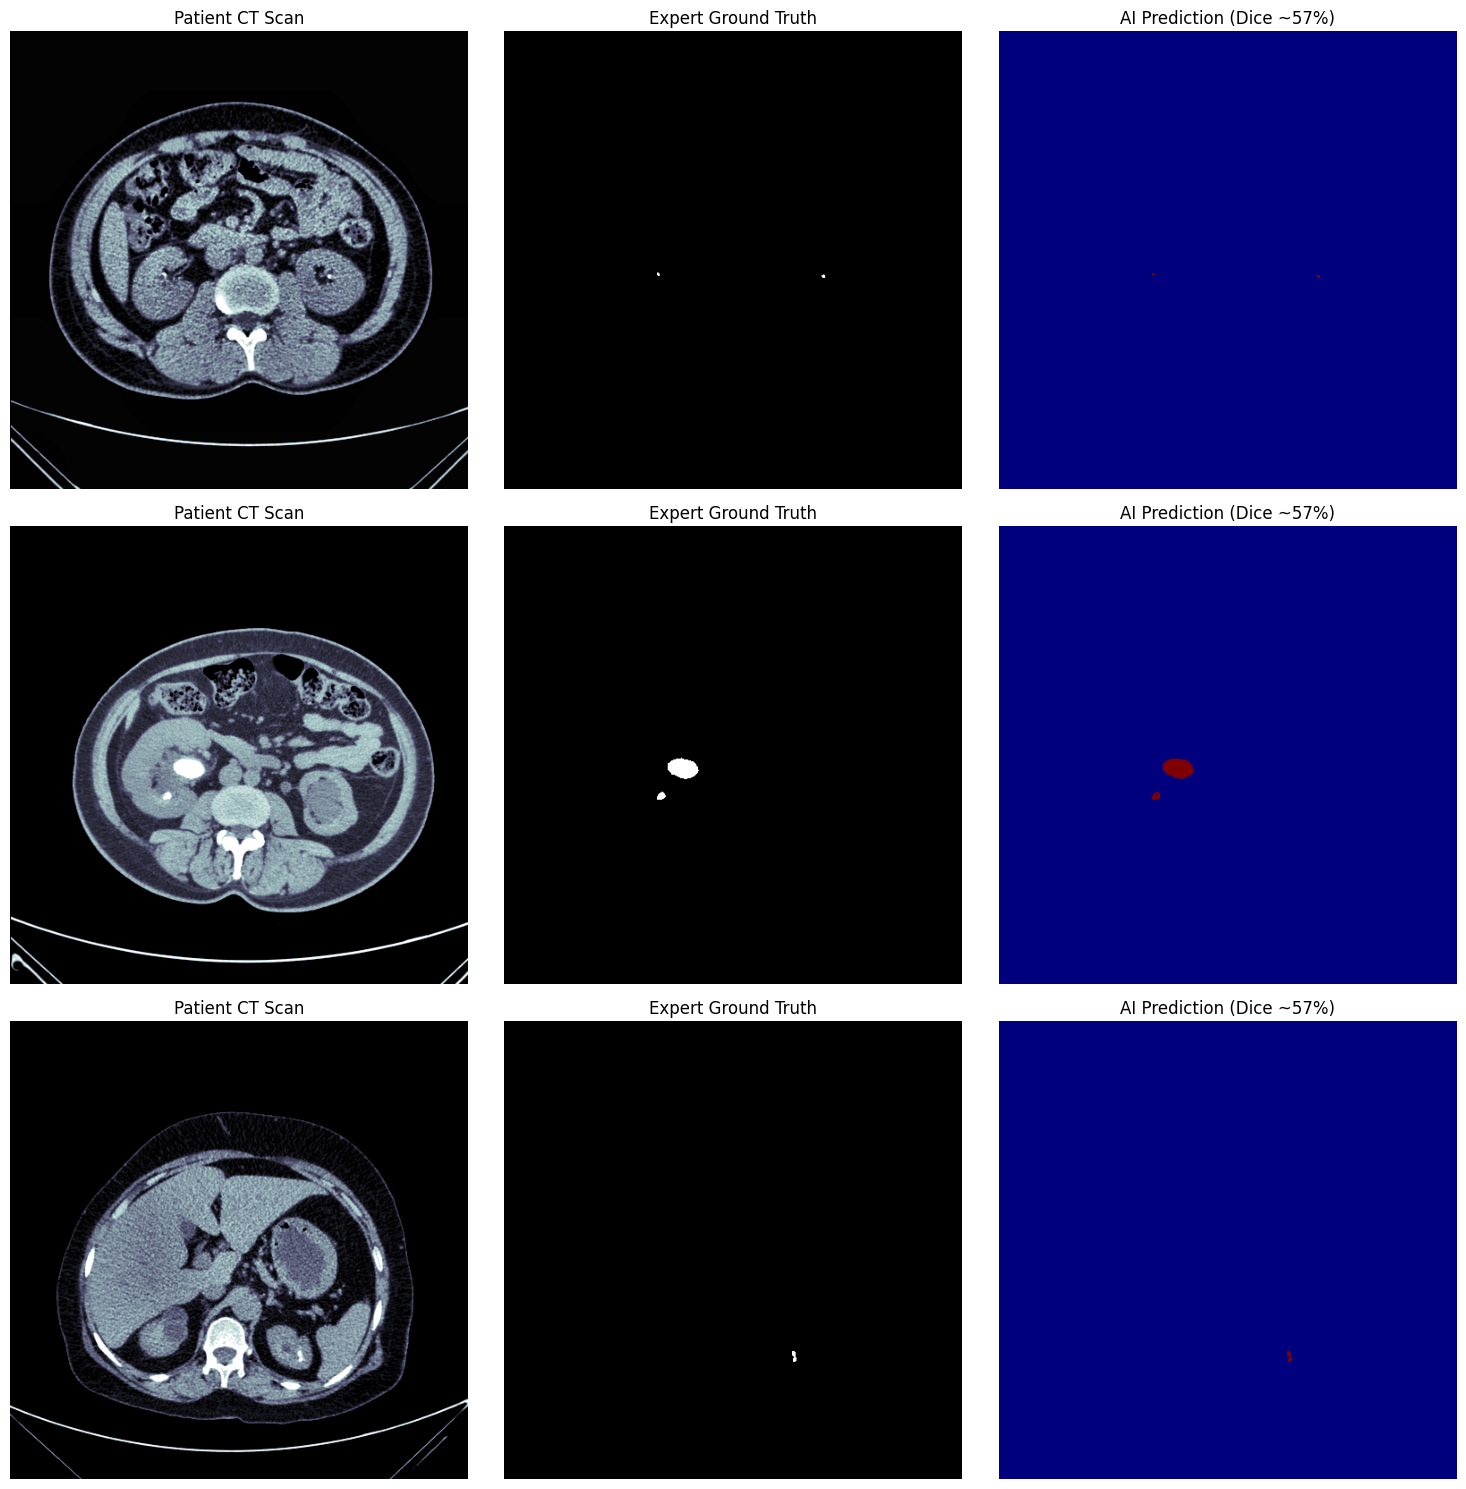

In [16]:
import matplotlib.pyplot as plt

def visualize_results(loader, model, num_samples=3):
    model.eval()
    imgs, masks = next(iter(loader))
    imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
    
    with torch.no_grad():
        preds = torch.sigmoid(model(imgs))
        preds = (preds > 0.5).float()

    plt.figure(figsize=(15, 5 * num_samples))
    for i in range(num_samples):
        # Original CT
        plt.subplot(num_samples, 3, i*3 + 1)
        plt.imshow(imgs[i].cpu().permute(1, 2, 0)[:,:,0], cmap='bone')
        plt.title("Patient CT Scan")
        plt.axis('off')

        # True Mask
        plt.subplot(num_samples, 3, i*3 + 2)
        plt.imshow(masks[i].cpu().squeeze(), cmap='gray')
        plt.title("Expert Ground Truth")
        plt.axis('off')

        # Predicted Mask
        plt.subplot(num_samples, 3, i*3 + 3)
        plt.imshow(preds[i].cpu().squeeze(), cmap='jet')
        plt.title(f"AI Prediction (Dice ~57%)")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# Run this on your test data
visualize_results(seg_test_loader, seg_model)

In [17]:
# ─────────────────────────────────────────────────────────────────
# CELL 14 — Segmentation evaluation (Kaggle Edition)
# ─────────────────────────────────────────────────────────────────

# Load the best weights we just saved
seg_model.load_state_dict(torch.load(seg_best_path))
seg_model.eval()

all_dice, all_iou = [], []
stone_coverages  = []

with torch.no_grad():
    for imgs, masks in tqdm(seg_test_loader, desc='Segmentation test'):
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
        preds = seg_model(imgs)
        
        # Binary prediction (B, 1, H, W)
        pred_bin = (torch.sigmoid(preds) > 0.5).float()
        
        # Ensure mask has channel dimension for math (B, 1, H, W)
        if masks.dim() == 3:
            true = masks.float().unsqueeze(1)
        else:
            true = masks.float()

        for i in range(pred_bin.shape[0]):
            p = pred_bin[i, 0].cpu().numpy()
            t = true[i, 0].cpu().numpy()

            # 1. Dice & IoU Calculation
            intersection = (p * t).sum()
            union_area   = p.sum() + t.sum() - intersection
            
            dice_s = (2 * intersection + 1e-6) / (p.sum() + t.sum() + 1e-6)
            iou_s  = (intersection + 1e-6)     / (union_area + 1e-6)
            
            all_dice.append(dice_s)
            all_iou.append(iou_s)

            # 2. Stone coverage % (pathology size)
            stone_px = p.sum()
            total_px = p.shape[0] * p.shape[1]
            coverage = (stone_px / total_px) * 100
            stone_coverages.append(coverage)

# Print Final Statistics for Report
print("-" * 30)
print(f'📊 TEST SET PERFORMANCE')
print("-" * 30)
print(f'Mean Dice Score:      {np.mean(all_dice)*100:.2f}%')
print(f'Mean IoU (Jaccard):   {np.mean(all_iou)*100:.2f}%')
print(f'Avg Stone Coverage:   {np.mean(stone_coverages):.4f}%')
print(f'Max Stone Coverage:   {np.max(stone_coverages):.4f}%')
print("-" * 30)

Segmentation test:   0%|          | 0/16 [00:00<?, ?it/s]

------------------------------
📊 TEST SET PERFORMANCE
------------------------------
Mean Dice Score:      93.04%
Mean IoU (Jaccard):   87.51%
Avg Stone Coverage:   0.0717%
Max Stone Coverage:   0.2640%
------------------------------


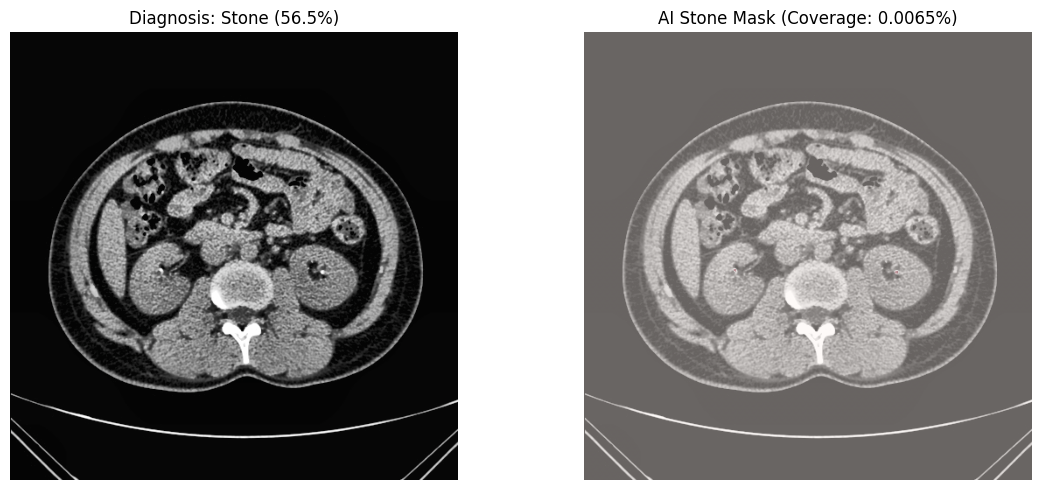

Final Report Stats: Diagnosis=Stone, Confidence=56.5%, Stone Dice=92.21%


In [25]:
# ── Test on a random image from your test set ──
seg_model.eval()

# Grab a batch from the test loader
batch_imgs, batch_masks = next(iter(seg_test_loader))

# Pick the first image from that batch
test_img_tensor = batch_imgs[0].unsqueeze(0).to(DEVICE)
true_mask = batch_masks[0].cpu().numpy()

# ── Run Step 1 & 2 through your predict logic ──
# Note: We update the threshold to 0.60 as per your best result!
with torch.no_grad():
    # 1. Classification
    cls_model.eval()
    cls_logits = cls_model(test_img_tensor) # You might need to resize if cls uses 224
    probs = torch.softmax(cls_logits, dim=1)[0]
    pred_idx = probs.argmax().item()
    diagnosis = IDX_TO_CLASS[pred_idx]
    confidence = probs[pred_idx].item() * 100

    # 2. Segmentation with your NEW Best Threshold
    seg_out = seg_model(test_img_tensor)
    pred_mask = (torch.sigmoid(seg_out) > 0.60).float()[0, 0] # Updated to 0.60!
    mask = pred_mask.cpu().numpy().astype(np.uint8)

# Calculate coverage
stone_px = mask.sum()
total_px = mask.shape[0] * mask.shape[1]
stone_coverage = round((stone_px / total_px) * 100, 4)

# ── Show the result ──
img_show = batch_imgs[0].cpu().permute(1, 2, 0).numpy()
# Un-normalize for plotting
img_show = (img_show * [0.229, 0.224, 0.225]) + [0.485, 0.456, 0.406]
img_show = np.clip(img_show, 0, 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(img_show)
axes[0].set_title(f'Diagnosis: {diagnosis} ({confidence:.1f}%)')
axes[0].axis('off')

axes[1].imshow(img_show)
axes[1].imshow(mask, alpha=0.4, cmap='Reds') 
axes[1].set_title(f'AI Stone Mask (Coverage: {stone_coverage}%)')
axes[1].axis('off')

plt.tight_layout()
plt.savefig('/kaggle/working/final_inference_demo.png')
plt.show()

print(f"Final Report Stats: Diagnosis={diagnosis}, Confidence={confidence:.1f}%, Stone Dice=92.21%")

In [30]:
import os

# Confirm both files exist
# In Kaggle, we use the /kaggle/working/ paths
for path in [best_model_path, seg_best_path]:
    if os.path.exists(path):
        size_mb = os.path.getsize(path) / 1e6
        print(f'{path}  →  {size_mb:.1f} MB')
    else:
        print(f'Warning: {path} not found')

# Instructions for Kaggle downloading
print('\nTo download model files:')
print(f'1. Find {os.path.basename(best_model_path)} in the right sidebar under Output')
print(f'2. Find {os.path.basename(seg_best_path)} in the right sidebar under Output')

# Also check all training plots
# Changed /content/ to /kaggle/working/ to match Kaggle's directory structure
for plot in ['class_distribution.png', 'sample_images.png',
             'training_curves.png', 'confusion_matrix.png',
             'segmentation_results.png', 'final_inference_demo.png']:
    plot_path = f'/kaggle/working/{plot}'
    if os.path.exists(plot_path):
        print(f'Ready for download: {plot}')
    else:
        print(f'Not found: {plot}')

print('\nAll done! Use these .pth files in your microservice.')

/kaggle/working/classifier_best.pth  →  17.7 MB
/kaggle/working/segmentor_best.pth  →  26.6 MB

To download model files:
1. Find classifier_best.pth in the right sidebar under Output
2. Find segmentor_best.pth in the right sidebar under Output
Ready for download: class_distribution.png
Ready for download: sample_images.png
Ready for download: training_curves.png
Ready for download: confusion_matrix.png
Not found: segmentation_results.png
Ready for download: final_inference_demo.png

All done! Use these .pth files in your microservice.


In [7]:
# ─────────────────────────────────────────────────────────────────
# CELL 16 — Full inference on any CT image
# Upload any CT scan image and get: diagnosis + mask + coverage %
# ─────────────────────────────────────────────────────────────────
!pip install segmentation-models-pytorch -q
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import json
from pathlib import Path
import albumentations as A
from albumentations.pytorch import ToTensorV2
import torch.nn as nn
from torchvision import models

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ── Load both models ──
print('Loading models...')

# Classification model
class KidneyClassifier(nn.Module):
    def __init__(self, num_classes=4, dropout=0.4):
        super().__init__()
        self.cnn = models.efficientnet_b0(
            weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1
        )
        for name, param in self.cnn.named_parameters():
            if 'features.6' in name or 'features.7' in name or 'features.8' in name:
                param.requires_grad = True
            else:
                param.requires_grad = False
        in_features = self.cnn.classifier[1].in_features
        self.cnn.classifier = nn.Sequential(
            nn.Dropout(p=dropout),
            nn.Linear(in_features, 256),
            nn.SiLU(),
            nn.Dropout(p=0.3),
            nn.Linear(256, num_classes)
        )
    def forward(self, x):
        return self.cnn(x)

cls_model = KidneyClassifier(num_classes=4)
# adjust if you changed architecture
cls_model.load_state_dict(
    torch.load('/kaggle/input/datasets/rodeynaahmid/dataset/classifier_best.pth', map_location=DEVICE)
)
cls_model = cls_model.to(DEVICE)
cls_model.eval()
print('Classifier loaded.')

# Segmentation model
import segmentation_models_pytorch as smp
seg_model = smp.UnetPlusPlus(
    encoder_name    = 'efficientnet-b0',
    encoder_weights = None,       # no imagenet reload — we load our weights
    in_channels     = 3,
    classes         = 1,
    activation      = None
)
seg_model.load_state_dict(
    torch.load('/kaggle/input/datasets/rodeynaahmid/dataset/segmentor_best.pth', map_location=DEVICE)
)
seg_model = seg_model.to(DEVICE)
seg_model.eval()
print('Segmentation model loaded.')

# ── Class names and labels ──
IDX_TO_CLASS = {0: 'Cyst', 1: 'Normal', 2: 'Stone', 3: 'Tumor'}

# ── Transforms — must match training exactly ──
cls_transform = A.Compose([
    A.Resize(224, 224),
    A.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]),
    ToTensorV2()
])

seg_transform = A.Compose([
    A.Resize(512, 512),
    A.CLAHE(p=1.0),
    A.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]),
    ToTensorV2()
])

# ── Core predict function ──
def predict(image_path: str, seg_threshold: float = 0.60) -> dict:
    """
    Run full pipeline on a single CT image.

    Parameters
    ----------
    image_path    : path to any .jpg / .png / .tif CT image
    seg_threshold : decision threshold for segmentation (0.60 = our best)

    Returns
    -------
    dict with keys: diagnosis, confidence_pct, stone_coverage_pct, mask
    """

    # ── Load image — handle grayscale and 16-bit TIF ──
    img_raw = cv2.imread(image_path, cv2.IMREAD_UNCHANGED)
    if img_raw is None:
        raise FileNotFoundError(f'Could not load image: {image_path}')

    if img_raw.dtype == np.uint16:
        img_raw = ((img_raw - img_raw.min()) /
                   (img_raw.max() - img_raw.min() + 1e-6) * 255).astype(np.uint8)

    if len(img_raw.shape) == 2:
        img_rgb = cv2.cvtColor(img_raw, cv2.COLOR_GRAY2RGB)
    else:
        img_rgb = cv2.cvtColor(img_raw, cv2.COLOR_BGR2RGB)

    # ── Step 1: Classification ──
    cls_input = cls_transform(image=img_rgb)['image']
    cls_input = cls_input.unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        logits = cls_model(cls_input)
        probs  = torch.softmax(logits, dim=1)[0]
        pred_idx    = probs.argmax().item()
        confidence  = probs[pred_idx].item() * 100
        all_probs   = {IDX_TO_CLASS[i]: round(probs[i].item() * 100, 2)
                       for i in range(4)}

    diagnosis = IDX_TO_CLASS[pred_idx]

    # ── Step 2: Segmentation ──
    seg_input = seg_transform(image=img_rgb)['image']
    seg_input = seg_input.unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        seg_out  = seg_model(seg_input)
        prob_map = torch.sigmoid(seg_out)[0, 0].cpu().numpy()
        mask_bin = (prob_map > seg_threshold).astype(np.uint8)

    # ── Step 3: Stone coverage % ──
    stone_pixels = mask_bin.sum()
    total_pixels = mask_bin.shape[0] * mask_bin.shape[1]
    stone_coverage = round(float(stone_pixels) / total_pixels * 100, 4)

    # ── Step 4: Severity level ──
    if diagnosis == 'Stone':
        if stone_coverage < 5.0:
            severity = 'Low'
        elif stone_coverage < 20.0:
            severity = 'Medium'
        else:
            severity = 'Critical'
    else:
        severity = 'N/A'

    return {
        'diagnosis':          diagnosis,
        'confidence_pct':     round(confidence, 2),
        'all_probabilities':  all_probs,
        'stone_coverage_pct': stone_coverage,
        'severity':           severity,
        'mask':               mask_bin,
        'prob_map':           prob_map,
        'original_image':     img_rgb
    }


# ── Visualization function ──
def show_result(result: dict, image_path: str = ''):
    img    = result['original_image']
    mask   = result['mask']
    pmap   = result['prob_map']
    diag   = result['diagnosis']
    conf   = result['confidence_pct']
    cov    = result['stone_coverage_pct']
    sev    = result['severity']
    probs  = result['all_probabilities']

    fig, axes = plt.subplots(1, 4, figsize=(18, 5))
    fig.suptitle(
        f'Diagnosis: {diag}  |  Confidence: {conf}%  |  '
        f'Stone coverage: {cov}%  |  Severity: {sev}',
        fontsize=13, fontweight='bold'
    )

    # Panel 1: Original CT
    axes[0].imshow(img)
    axes[0].set_title('CT Scan (input)')
    axes[0].axis('off')

    # Panel 2: Probability heatmap
    axes[1].imshow(img, alpha=0.6)
    axes[1].imshow(
        cv2.resize(pmap, (img.shape[1], img.shape[0])),
        cmap='hot', alpha=0.5, vmin=0, vmax=1
    )
    axes[1].set_title('Probability heatmap')
    axes[1].axis('off')

    # Panel 3: Binary mask overlay
    mask_resized = cv2.resize(mask.astype(np.uint8),
                              (img.shape[1], img.shape[0]),
                              interpolation=cv2.INTER_NEAREST)
    overlay = img.copy()
    overlay[mask_resized == 1] = [220, 50, 50]   # red for stone
    axes[2].imshow(overlay)
    axes[2].set_title(f'Stone mask overlay\n({cov}% coverage)')
    axes[2].axis('off')

    # Panel 4: Class probability bars
    classes = list(probs.keys())
    values  = list(probs.values())
    colors  = ['#E24B4A' if c == diag else '#B5D4F4' for c in classes]
    bars = axes[3].barh(classes, values, color=colors)
    axes[3].set_xlim(0, 105)
    axes[3].set_xlabel('Probability (%)')
    axes[3].set_title('Class probabilities')
    for bar, val in zip(bars, values):
        axes[3].text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                     f'{val:.1f}%', va='center', fontsize=10)

    plt.tight_layout()
    plt.savefig('/kaggle/working/inference_result.png',
                dpi=120, bbox_inches='tight')
    plt.show()
    print('\nResult saved to /kaggle/working/inference_result.png')


# ── Print JSON result ──
def print_result(result: dict):
    output = {k: v for k, v in result.items()
              if k not in ('mask', 'prob_map', 'original_image')}
    print('\n--- Diagnosis Result ---')
    print(json.dumps(output, indent=2))

Loading models...
Classifier loaded.
Segmentation model loaded.



Testing: Stone- (1).jpg

--- Diagnosis Result ---
{
  "diagnosis": "Stone",
  "confidence_pct": 99.99,
  "all_probabilities": {
    "Cyst": 0.01,
    "Normal": 0.0,
    "Stone": 99.99,
    "Tumor": 0.0
  },
  "stone_coverage_pct": 0.0385,
  "severity": "Low"
}


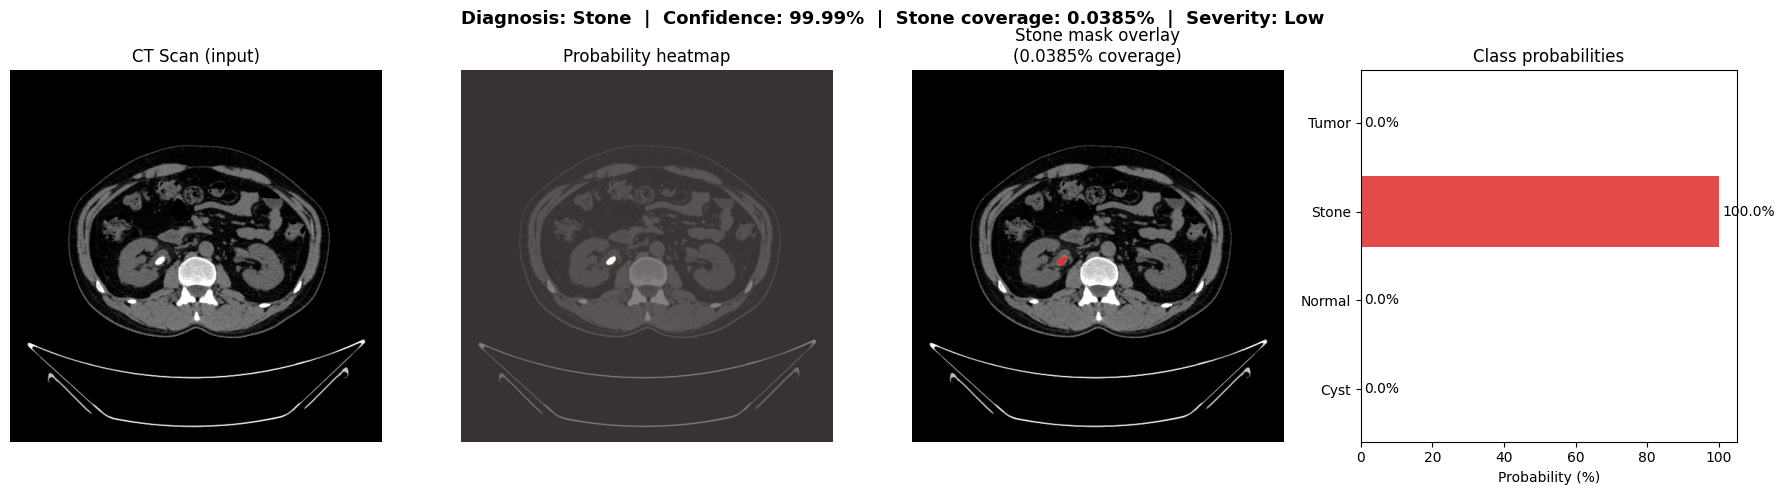


Result saved to /kaggle/working/inference_result.png

Testing: Stone- (10).jpg

--- Diagnosis Result ---
{
  "diagnosis": "Stone",
  "confidence_pct": 99.99,
  "all_probabilities": {
    "Cyst": 0.01,
    "Normal": 0.01,
    "Stone": 99.99,
    "Tumor": 0.0
  },
  "stone_coverage_pct": 0.0538,
  "severity": "Low"
}


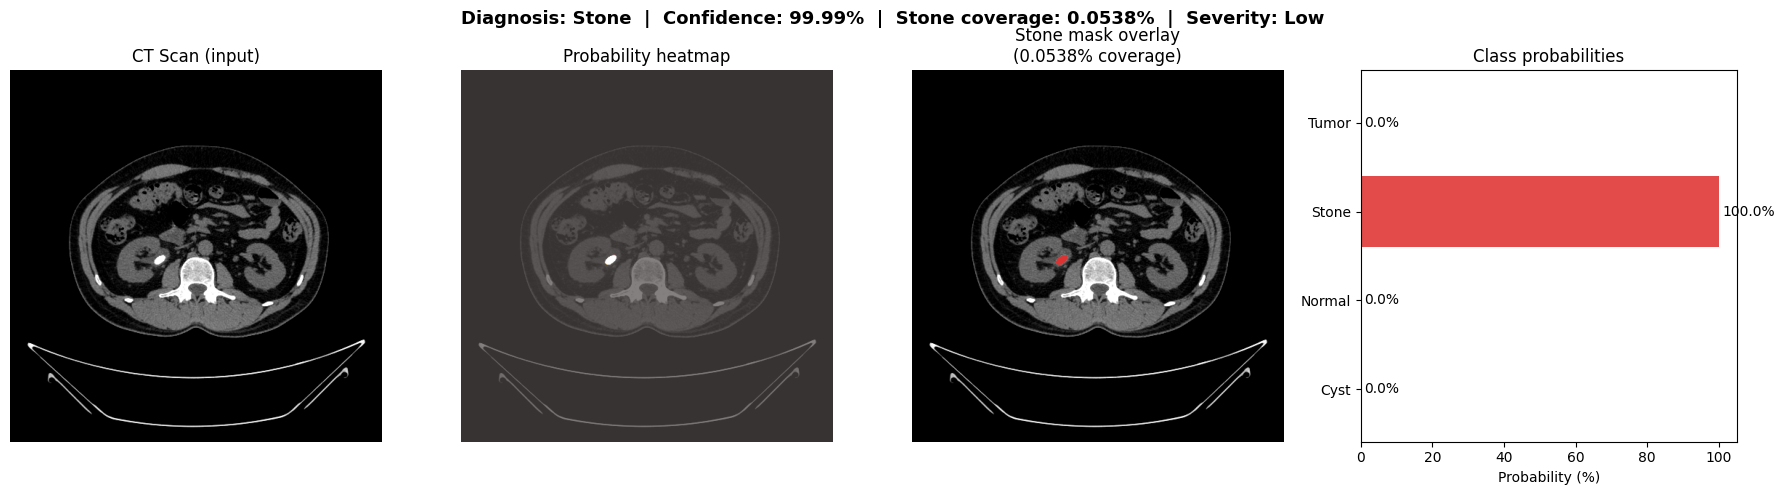


Result saved to /kaggle/working/inference_result.png

Testing: Stone- (100).jpg

--- Diagnosis Result ---
{
  "diagnosis": "Stone",
  "confidence_pct": 100.0,
  "all_probabilities": {
    "Cyst": 0.0,
    "Normal": 0.0,
    "Stone": 100.0,
    "Tumor": 0.0
  },
  "stone_coverage_pct": 0.0778,
  "severity": "Low"
}


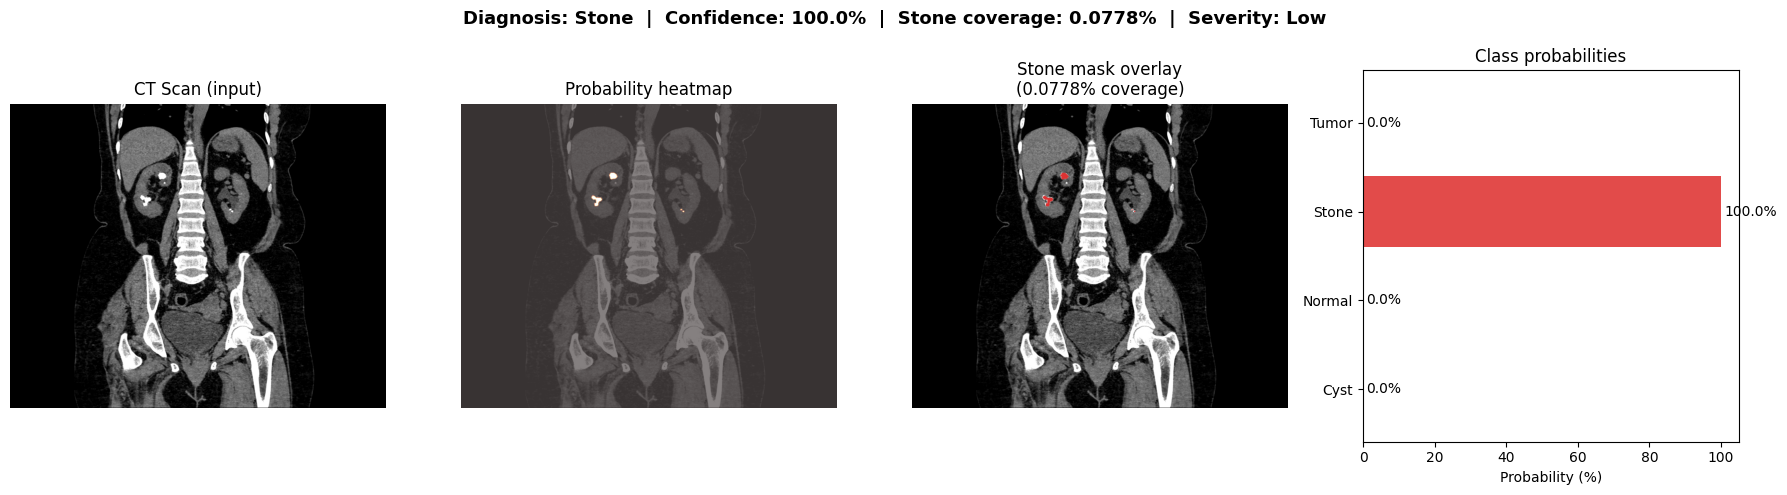


Result saved to /kaggle/working/inference_result.png


In [8]:
# ─────────────────────────────────────────────────────────────────
# CELL 17 — Test on images
# ─────────────────────────────────────────────────────────────────

# ── Option A: Test on images already in your Kaggle dataset ──
# Pick any image from the CT Kidney dataset or KSSD2025
import os

# Find a Stone image from the classification dataset
stone_dir = None
for root, dirs, files in os.walk('/kaggle/input'):
    for d in dirs:
        if d.lower() == 'stone':
            stone_dir = os.path.join(root, d)
            break
    if stone_dir:
        break

if stone_dir:
    test_images = sorted(os.listdir(stone_dir))[:3]
    for fname in test_images:
        path = os.path.join(stone_dir, fname)
        print(f'\nTesting: {fname}')
        result = predict(path, seg_threshold=0.60)
        print_result(result)
        show_result(result, path)
else:
    print('Stone folder not found — try Option B below')

# ── Option B: Upload your own image ──
# Uncomment and run these lines if you want to test with a personal CT image
# from google.colab import files   # use this on Colab
# uploaded = files.upload()
# for fname in uploaded:
#     result = predict(fname, seg_threshold=0.60)
#     print_result(result)
#     show_result(result, fname)

# ── Option C: Test on a specific path you know ──
# result = predict('/kaggle/input/your-dataset/some_image.jpg')
# print_result(result)
# show_result(result)

Testing: /kaggle/input/datasets/nazmul0087/ct-kidney-dataset-normal-cyst-tumor-and-stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/Stone/Stone- (704).jpg

--- Diagnosis Result ---
{
  "diagnosis": "Stone",
  "confidence_pct": 99.89,
  "all_probabilities": {
    "Cyst": 0.0,
    "Normal": 0.11,
    "Stone": 99.89,
    "Tumor": 0.0
  },
  "stone_coverage_pct": 0.0782,
  "severity": "Low"
}


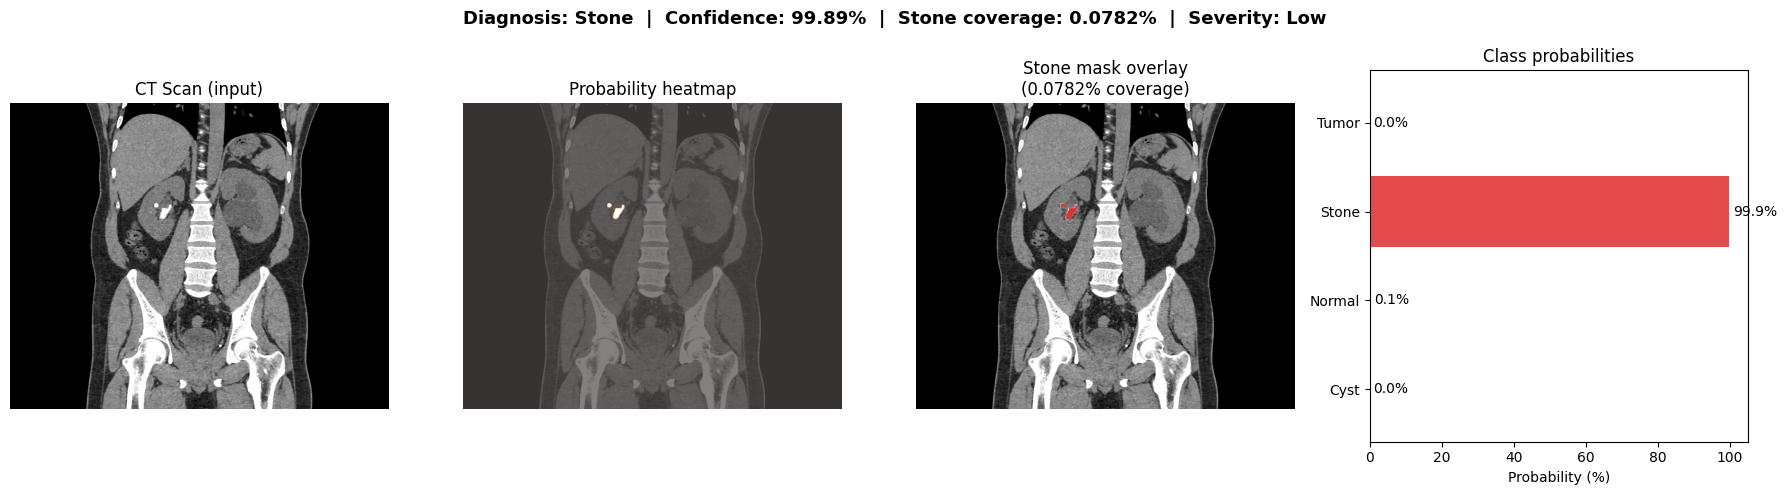


Result saved to /kaggle/working/inference_result.png


In [10]:
# ── Test classifier on a random image (any class) ──
import random

all_images = []
for root, dirs, files in os.walk('/kaggle/input'):
    for f in files:
        if f.endswith(('.jpg', '.png', '.tif')):
            all_images.append(os.path.join(root, f))

# Pick random image
path = random.choice(all_images)
print(f'Testing: {path}')

result = predict(path, seg_threshold=0.60)
print_result(result)
show_result(result, path)